In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Given a portfolio of Mu = 5%, 6%, 8%, 6%
# Volatility vecotr = 15%, 20%, 25%, 30%
# correlation matrix =[ [1.0, 0.1, 0.4, 0.5], [0.1, 1.0, 0.7, 0.4], [0.4, 0.7, 1.0, 0.8],[0.5, 0.4, 0.8, 1.0],]

In [4]:
np.random.seed(1)
n = 4
mu = np.array([0.05, 0.06, 0.08, 0.06]).flatten()
individual_sigma = np.diag([0.15, 0.2, 0.25, 0.3])
r = np.array(
    [
        [1.0, 0.1, 0.4, 0.5],
        [0.1, 1.0, 0.7, 0.4],
        [0.4, 0.7, 1.0, 0.8],
        [0.5, 0.4, 0.8, 1.0],
    ]
)

sigma_mat = individual_sigma @ r @ individual_sigma
sigma_mat

array([[0.0225, 0.003 , 0.015 , 0.0225],
       [0.003 , 0.04  , 0.035 , 0.024 ],
       [0.015 , 0.035 , 0.0625, 0.06  ],
       [0.0225, 0.024 , 0.06  , 0.09  ]])

In [13]:
w = cp.Variable(n)
gamma = cp.Parameter(nonneg=True)
ret = mu.T @ w
risk = cp.quad_form(w, sigma_mat)
prob = cp.Problem(cp.Maximize(ret - gamma * risk), [cp.sum(w) == 1])

In [26]:
_SAMPLES = 200
risk_data = np.zeros(_SAMPLES)
ret_data = np.zeros(_SAMPLES)
gamma_vals = np.logspace(-0.5, 2, num=_SAMPLES)
for i in range(_SAMPLES):
    gamma.value = gamma_vals[i]
    prob.solve()
    risk_data[i] = cp.sqrt(risk).value
    ret_data[i] = ret.value

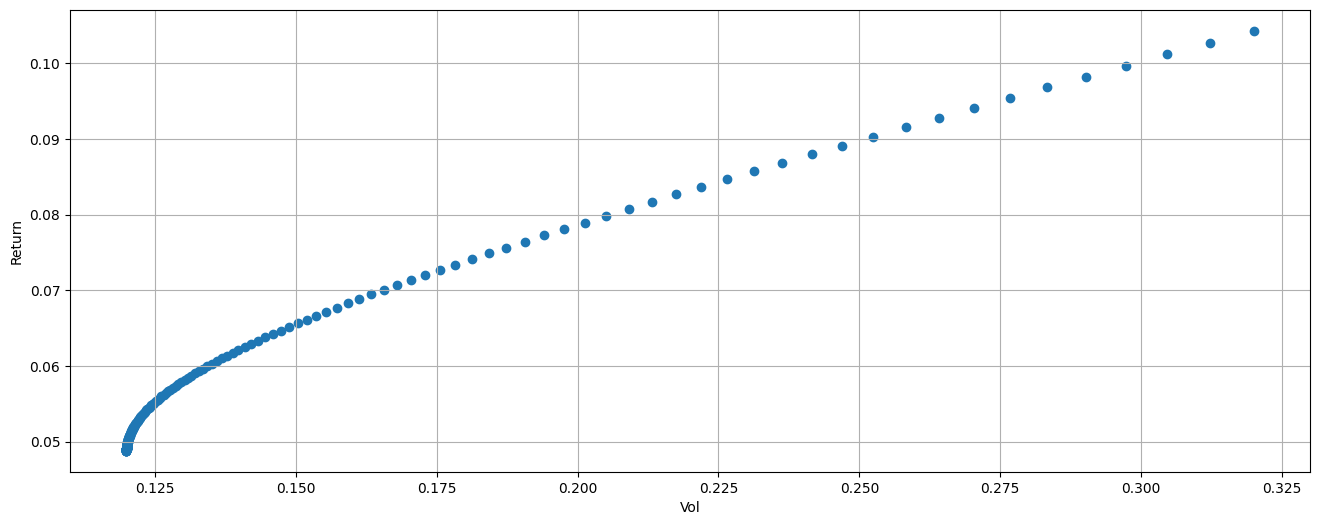

In [27]:
plt.figure(figsize=(16, 6))
plt.scatter(risk_data, ret_data)
plt.grid()
plt.xlabel("Vol")
plt.ylabel("Return")
plt.show()

In [28]:
def find_optimal_portfolio(gamma_range: list[float, float], target: float, is_mu: bool):
    def bisection_method(tmp_gamma):
        nonlocal target, is_mu
        gamma.value = tmp_gamma
        prob.solve()
        if is_mu:
            return ret.value - target
        else:
            return cp.sqrt(risk).value - target

    out = optimize.bisect(bisection_method, gamma_range[0], gamma_range[1])
    gamma.value = out
    prob.solve()
    print("optimal risk:", cp.sqrt(risk).value, "optimal return:", ret.value)
    return out, float(cp.sqrt(risk).value), ret.value

In [32]:
find_optimal_portfolio(gamma_range=[0.01, 100], target=0.2246, is_mu=True)

optimal risk: 0.9455771008311643 optimal return: 0.22460000000109515


(0.10001105435215109, 0.9455771008311643, 0.22460000000109515)

# With positive weight constraint

In [57]:
w = cp.Variable(n)
gamma = cp.Parameter(nonneg=True)
ret = mu.T @ w
risk = cp.quad_form(w, sigma_mat)
prob2 = cp.Problem(cp.Maximize(ret - gamma * risk), [cp.sum(w) == 1, w >= 0])

In [58]:
_SAMPLES = 200
risk_data_with_con = np.zeros(_SAMPLES)
ret_data_with_con = np.zeros(_SAMPLES)
gamma_vals = np.logspace(-0.5, 2, num=_SAMPLES)
for i in range(_SAMPLES):
    gamma.value = gamma_vals[i]
    prob2.solve()
    risk_data_with_con[i] = cp.sqrt(risk).value
    ret_data_with_con[i] = ret.value

# With 0 <= w_i <= 40%

In [59]:
w = cp.Variable(n)
gamma = cp.Parameter(nonneg=True)
ret = mu.T @ w
risk = cp.quad_form(w, sigma_mat)
prob3 = cp.Problem(
    cp.Maximize(ret - gamma * risk), [cp.sum(w) == 1, w >= 0.0, w <= 0.4]
)

In [63]:
_SAMPLES = 1000
risk_data_with_con2 = np.zeros(_SAMPLES)
ret_data_with_con2 = np.zeros(_SAMPLES)
gamma_vals = np.logspace(-0.5, 3, num=_SAMPLES)
for i in range(_SAMPLES):
    gamma.value = gamma_vals[i]
    prob3.solve()
    risk_data_with_con2[i] = cp.sqrt(risk).value
    ret_data_with_con2[i] = ret.value

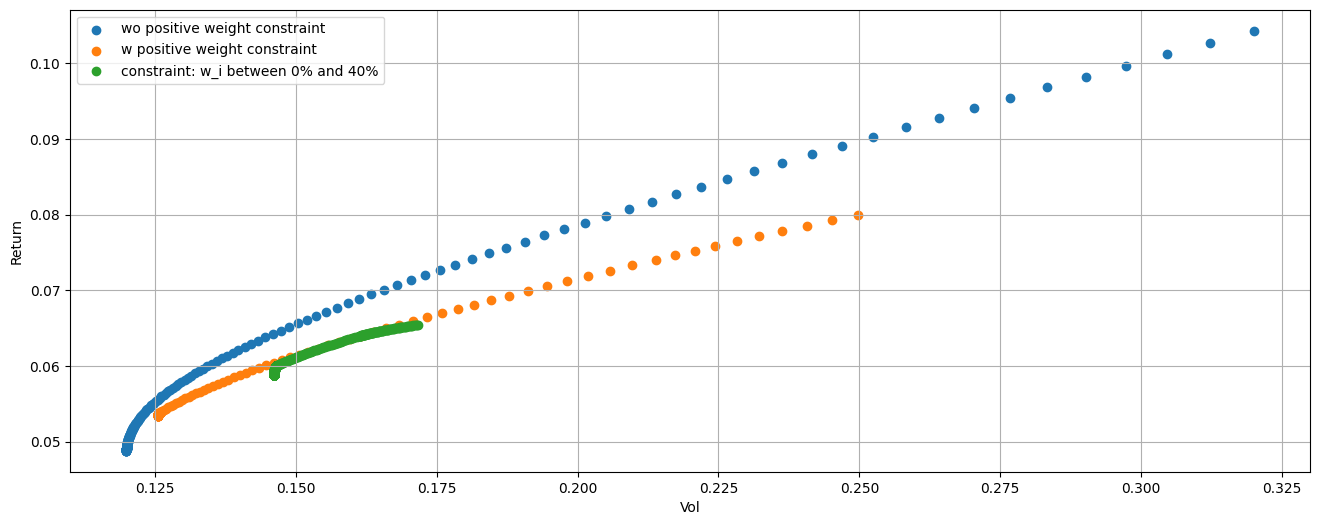

In [65]:
plt.figure(figsize=(16, 6))
plt.scatter(risk_data, ret_data, label="wo positive weight constraint")
plt.scatter(risk_data_with_con, ret_data_with_con, label="w positive weight constraint")
plt.scatter(
    risk_data_with_con2,
    ret_data_with_con2,
    label="constraint: w_i between 0% and 40%",
)
plt.grid()
plt.xlabel("Vol")
plt.ylabel("Return")
plt.legend()
plt.show()